In [14]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
from experiment_utils import save_result_v1,save_result, run_one_experiment, run, MLPClassifier

In [2]:
data = pd.read_csv('../data/Processed_Project_Data/fifa_and_elo_with_ema_and_strength_adjusted_margin_no_initial.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1110 entries, 0 to 1109
Data columns (total 53 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Unnamed: 0                           1110 non-null   int64  
 1   date                                 1110 non-null   str    
 2   home_team                            1110 non-null   str    
 3   away_team                            1110 non-null   str    
 4   home_score                           1110 non-null   float64
 5   away_score                           1110 non-null   float64
 6   tournament                           1110 non-null   str    
 7   city                                 1110 non-null   str    
 8   country                              1110 non-null   str    
 9   neutral                              1110 non-null   int64  
 10  year                                 1110 non-null   int64  
 11  is_world_cup                         1110

In [3]:
data.drop(columns='Unnamed: 0', inplace = True)

In [4]:
data

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,...,away_form_ema25,form_diff_sma3,form_diff_sma5,form_diff_sma7,form_diff_ema50,form_diff_ema33,form_diff_ema25,home_strength_adjusted_margin_ema33,away_strength_adjusted_margin_ema33,strength_adjusted_margin_diff_ema33
0,2022-01-30,Mexico,Costa Rica,0.0,0.0,FIFA World Cup qualification,Mexico City,Mexico,0,2022,...,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.140000,0.720000,-0.580000
1,2022-01-30,Canada,United States,2.0,0.0,FIFA World Cup qualification,Hamilton,Canada,0,2022,...,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.280000,-0.180000,1.460000
2,2022-01-30,Honduras,El Salvador,0.0,2.0,FIFA World Cup qualification,San Pedro Sula,Honduras,0,2022,...,-1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-1.280000,0.180000,-1.460000
3,2022-01-30,Panama,Jamaica,3.0,2.0,FIFA World Cup qualification,Panama City,Panama,0,2022,...,-1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.720000,-0.140000,-0.580000
4,2022-02-01,Uruguay,Venezuela,4.0,1.0,FIFA World Cup qualification,Montevideo,Uruguay,0,2022,...,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.480000,2.640000,-2.160000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105,2026-03-31,DR Congo,Jamaica,1.0,0.0,FIFA World Cup qualification,Zapopan,Mexico,1,2026,...,0.415678,-0.333333,0.0,0.000000,-0.719750,-0.375065,-0.210536,0.375256,-0.230308,0.605563
1106,2026-03-31,Iraq,Bolivia,2.0,1.0,FIFA World Cup qualification,Guadalupe,Mexico,1,2026,...,0.247506,0.000000,0.4,0.142857,-0.074108,0.043355,0.124452,0.038068,-0.655560,0.693628
1107,2026-03-31,Bosnia and Herzegovina,Italy,1.0,1.0,FIFA World Cup qualification,Zenica,Bosnia and Herzegovina,0,2026,...,0.294071,0.000000,-0.6,-0.142857,-0.345703,-0.178987,0.004757,1.296829,-1.440242,2.737072
1108,2026-03-31,Czech Republic,Denmark,2.0,2.0,FIFA World Cup qualification,Prague,Czech Republic,0,2026,...,0.240176,0.000000,-0.2,-0.285714,-0.201172,-0.148086,-0.131638,-0.513348,-0.051590,-0.461758


In [5]:
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)

feature_cols = [
    "home_rank",
    "away_rank",
    "home_strength_adjusted_margin_ema33",
    "away_strength_adjusted_margin_ema33",
]

target_col = "result"


In [6]:
X = data[feature_cols]
y = data['result']

label_map = {
    -1: 0,   
     0: 1,  
     1: 2,   
}

y_enc = y.map(label_map)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, shuffle=False)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [8]:
X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [9]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8759 | val loss = 0.7317 | val acc = 0.6573
Epoch 100/1000 | train loss = 0.8802 | val loss = 0.7357 | val acc = 0.6573
Epoch 150/1000 | train loss = 0.8500 | val loss = 0.7366 | val acc = 0.6573
Epoch 200/1000 | train loss = 0.8589 | val loss = 0.7314 | val acc = 0.6573
Epoch 250/1000 | train loss = 0.8355 | val loss = 0.7433 | val acc = 0.6629
Epoch 300/1000 | train loss = 0.8433 | val loss = 0.7406 | val acc = 0.6517
Epoch 350/1000 | train loss = 0.8348 | val loss = 0.7322 | val acc = 0.6573
Epoch 400/1000 | train loss = 0.8335 | val loss = 0.7402 | val acc = 0.6292
Epoch 450/1000 | train loss = 0.8335 | val loss = 0.7391 | val acc = 0.6236
Epoch 500/1000 | train loss = 0.8224 | val loss = 0.7390 | val acc = 0.6236
Epoch 550/1000 | train loss = 0.7914 | val loss = 0.7330 | val acc = 0.6180
Epoch 600/1000 | train loss = 0.8074 | val loss = 0.7392 | val acc = 0.6236
Epoch 650/1000 | train loss = 0.8062 | val loss = 0.7283 | val acc = 0.6348
Epoch 700/100

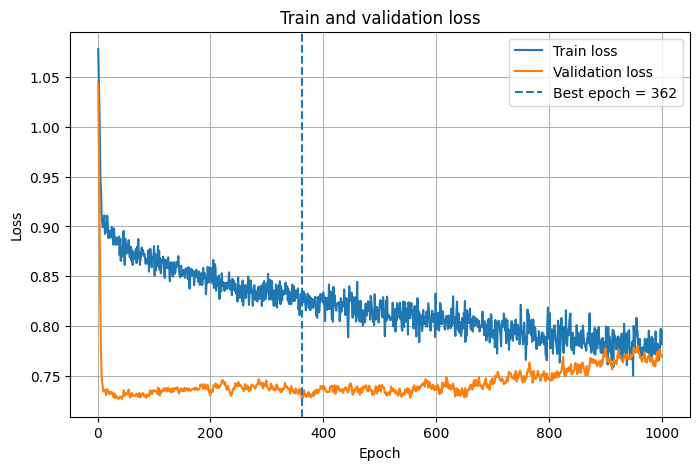

0.6531531531531531

In [10]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [11]:
best_num_epochs = 362

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.6532 | Precision: 0.6223 | Recall: 0.5532 | Specificity: 0.7971 | F1: 0.5229

Run 2/10
Accuracy: 0.6577 | Precision: 0.5481 | Recall: 0.5547 | Specificity: 0.8039 | F1: 0.5084

Run 3/10
Accuracy: 0.6622 | Precision: 0.7663 | Recall: 0.5618 | Specificity: 0.8016 | F1: 0.5208

Run 4/10
Accuracy: 0.6532 | Precision: 0.7613 | Recall: 0.5517 | Specificity: 0.7965 | F1: 0.5037

Run 5/10
Accuracy: 0.6441 | Precision: 0.4215 | Recall: 0.5375 | Specificity: 0.7940 | F1: 0.4724

Run 6/10
Accuracy: 0.6532 | Precision: 0.6296 | Recall: 0.5558 | Specificity: 0.7996 | F1: 0.5148

Run 7/10
Accuracy: 0.6577 | Precision: 0.5872 | Recall: 0.5629 | Specificity: 0.8032 | F1: 0.5297

Run 8/10
Accuracy: 0.6532 | Precision: 0.4305 | Recall: 0.5435 | Specificity: 0.7956 | F1: 0.4804

Run 9/10
Accuracy: 0.6622 | Precision: 0.6566 | Recall: 0.5577 | Specificity: 0.8036 | F1: 0.5095

Run 10/10
Accuracy: 0.6622 | Precision: 0.6836 | Recall: 0.5640 | Specificity: 0.8045 | F1: 0.5212

Summary o

In [13]:
save_result_v1(
    experiment_name="Experiment_4-1_FIFA_rank_goal_diff_EMA",
    summary=summary
)


Saved result for Experiment_4-1_FIFA_rank_goal_diff_EMA
File: ../results/experiment_summary_v1.csv


In [15]:
save_result(
    experiment_name="Experiment_4-1_FIFA_rank_goal_diff_EMA",
    summary=summary
)


Saved result for Experiment_4-1_FIFA_rank_goal_diff_EMA
File: ../results/experiment_summary_final.csv
